# Análisis de tiempos de respuesta en servicios de refrigeración comercial

**Autor:** Kenji Teramoto
**Herramientas:** Python · pandas · matplotlib

---

## Contexto

En una operación de servicio de refrigeración comercial, cada falla genera un **folio** que un técnico
debe atender y cerrar. Cuando un equipo permanece fuera de servicio, el cliente pierde producto y ventas,
así que el tiempo de respuesta es el indicador crítico del negocio.

Este proyecto analiza **1,428 folios** de un año de operación en cinco regiones de México
para responder una pregunta concreta:

> **¿Qué factores explican que un servicio tarde más en cerrarse, y dónde conviene actuar primero?**

## Meta del negocio

El acuerdo de servicio (SLA) establece un objetivo de **cierre en 24 horas o menos**.
Queremos medir qué tanto se cumple y qué lo impide.

## Nota sobre los datos

El dataset es **sintético**, generado para este ejercicio, pero replica la estructura y los problemas
de calidad de un sistema real de gestión de servicios en campo: duplicados, capturas inconsistentes,
valores nulos y errores de captura.

## 1. Carga de datos e inspección inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('../datos/servicios_refrigeracion.csv')
print(f'Filas: {df.shape[0]}   Columnas: {df.shape[1]}')
df.head()

Filas: 1428   Columnas: 14


,folio,fecha_apertura,fecha_cierre,cliente,region,tipo_equipo,tipo_servicio,falla_reportada,tecnico_id,requiere_refaccion,horas_respuesta,costo_servicio,reincidencia_30d,estatus
0,F-202500070,2025-06-21 07:00,2025-06-22 04:30,Cliente 045,Centro,Congelador horizontal,Preventivo,Mantenimiento programado,TEC-005,No,21.5,1983.71,No,Cerrado
1,F-202500922,2025-07-28 07:00,2025-07-30 03:54,Cliente 003,Centro,Refrigerador vertical,Correctivo,Acumulacion de hielo,TEC-025,No,44.9,12171.24,No,Cerrado
2,F-202501230,2025-04-16 07:00,2025-04-18 10:06,Cliente 045,Centro,Vitrina refrigerada,Correctivo,Fuga de refrigerante,TEC-010,Si,51.1,16178.75,No,Cerrado
3,F-202500596,2025-10-20 07:00,2025-10-22 18:42,Cliente 017,Occidente,Maquina de hielo,Correctivo,Acumulacion de hielo,TEC-032,Si,59.7,13724.46,No,Cerrado
4,F-202501240,2025-01-15 17:00,2025-01-17 23:54,Cliente 036,Centro,Vitrina refrigerada,Correctivo,Falla de compresor,TEC-017,Si,54.9,8785.58,No,Cerrado


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1428 entries, 0 to 1427
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   folio               1428 non-null   str    
 1   fecha_apertura      1428 non-null   str    
 2   fecha_cierre        1428 non-null   str    
 3   cliente             1428 non-null   str    
 4   region              1428 non-null   str    
 5   tipo_equipo         1428 non-null   str    
 6   tipo_servicio       1428 non-null   str    
 7   falla_reportada     1428 non-null   str    
 8   tecnico_id          1397 non-null   str    
 9   requiere_refaccion  1428 non-null   str    
 10  horas_respuesta     1382 non-null   float64
 11  costo_servicio      1406 non-null   float64
 12  reincidencia_30d    1428 non-null   str    
 13  estatus             1428 non-null   str    
dtypes: float64(2), str(12)
memory usage: 156.3 KB


### Diccionario de datos

| Columna | Descripción |
|---|---|
| `folio` | Identificador único del servicio |
| `fecha_apertura` / `fecha_cierre` | Momento de reporte y de cierre |
| `cliente` | Cliente que reporta |
| `region` | Región operativa |
| `tipo_equipo` | Equipo atendido |
| `tipo_servicio` | Correctivo, Preventivo o Instalación |
| `falla_reportada` | Causa reportada |
| `tecnico_id` | Técnico asignado |
| `requiere_refaccion` | Si el servicio necesitó una pieza |
| `horas_respuesta` | Horas entre apertura y cierre |
| `costo_servicio` | Costo en pesos |
| `reincidencia_30d` | Si el equipo volvió a fallar en 30 días |
| `estatus` | Estado del folio |

## 2. Diagnóstico de calidad de datos

Antes de analizar, hay que saber qué tan confiable es la información.

In [3]:
print('=== DUPLICADOS ===')
print(f'Filas duplicadas exactas: {df.duplicated().sum()}')

print('\n=== VALORES NULOS ===')
nulos = df.isna().sum()
print(nulos[nulos > 0])

print('\n=== CONSISTENCIA DE TEXTO ===')
print(f'Valores distintos en region: {df.region.nunique()}')
print(sorted(df.region.unique()))
print(f'\nValores distintos en estatus: {list(df.estatus.unique())}')

=== DUPLICADOS ===
Filas duplicadas exactas: 22

=== VALORES NULOS ===
tecnico_id         31
horas_respuesta    46
costo_servicio     22
dtype: int64

=== CONSISTENCIA DE TEXTO ===
Valores distintos en region: 20
[' Bajio ', ' Centro ', ' Norte ', ' Occidente ', ' Sureste ', 'BAJIO', 'Bajio', 'CENTRO', 'Centro', 'NORTE', 'Norte', 'OCCIDENTE', 'Occidente', 'SURESTE', 'Sureste', 'bajio', 'centro', 'norte', 'occidente', 'sureste']

Valores distintos en estatus: ['Cerrado', 'En proceso', 'cerrado']


**Tres problemas detectados:**

1. **22 filas duplicadas** — inflarían cualquier promedio.
2. **Nulos** en `horas_respuesta`, `tecnico_id` y `costo_servicio`.
3. **Inconsistencias de captura**: la misma región aparece escrita de varias formas
   (`Centro`, `CENTRO`, `centro`, ` Centro `) y lo mismo pasa con el estatus.
   Sin corregirlo, un agrupamiento por región daría 20 grupos en vez de 5.

In [4]:
print('=== VALORES FUERA DE RANGO EN horas_respuesta ===')
print(df.horas_respuesta.describe().round(1))
print(f'\nNegativos: {(df.horas_respuesta < 0).sum()}')
print(f'Mayores a 720 h (30 días): {(df.horas_respuesta > 720).sum()}')

=== VALORES FUERA DE RANGO EN horas_respuesta ===
count    1382.0
mean       55.0
std       181.5
min       -64.6
25%        19.8
50%        32.1
75%        50.2
max      2398.7
Name: horas_respuesta, dtype: float64

Negativos: 9
Mayores a 720 h (30 días): 14


Aparecen **horas negativas** (fecha de cierre anterior a la de apertura: captura invertida)
y **valores superiores a 720 horas**, imposibles en esta operación. Ambos son errores de captura
y hay que excluirlos para que no distorsionen los promedios.

## 3. Limpieza de datos

In [5]:
d = df.copy()
n0 = len(d)

# 1. Eliminar duplicados exactos
d = d.drop_duplicates()
print(f'Duplicados eliminados: {n0 - len(d)}')

# 2. Normalizar texto: quitar espacios y unificar mayúsculas
d['region'] = d['region'].str.strip().str.title()
d['estatus'] = d['estatus'].str.strip().str.capitalize()
print(f'Regiones tras normalizar: {sorted(d.region.unique())}')
print(f'Estatus tras normalizar: {list(d.estatus.unique())}')

# 3. Convertir fechas de texto a datetime
d['fecha_apertura'] = pd.to_datetime(d['fecha_apertura'])
d['fecha_cierre'] = pd.to_datetime(d['fecha_cierre'])

# 4. Descartar registros con horas inválidas
n1 = len(d)
d = d[(d['horas_respuesta'] > 0) & (d['horas_respuesta'] <= 720)]
d = d.dropna(subset=['horas_respuesta'])
print(f'Registros con horas inválidas o nulas descartados: {n1 - len(d)}')

print(f'\nDataset final: {len(d)} folios ({len(d)/n0:.1%} del original)')

Duplicados eliminados: 22
Regiones tras normalizar: ['Bajio', 'Centro', 'Norte', 'Occidente', 'Sureste']
Estatus tras normalizar: ['Cerrado', 'En proceso']
Registros con horas inválidas o nulas descartados: 69

Dataset final: 1337 folios (93.6% del original)


> **Decisión tomada:** los folios sin `horas_respuesta` se descartan porque esa variable es el eje
> del análisis y no puede imputarse sin inventar información. En cambio, los nulos de `tecnico_id`
> y `costo_servicio` se conservan, ya que solo afectan a análisis secundarios.

In [6]:
# Variables derivadas para el análisis
d['mes'] = d['fecha_apertura'].dt.month
d['dia_semana'] = d['fecha_apertura'].dt.dayofweek
d['fin_de_semana'] = d['dia_semana'] >= 5
d['cumple_sla'] = d['horas_respuesta'] <= 24   # SLA objetivo: 24 horas

print(f"Tiempo promedio de respuesta: {d.horas_respuesta.mean():.1f} h")
print(f"Mediana:                      {d.horas_respuesta.median():.1f} h")
print(f"Cumplimiento del SLA de 24 h: {d.cumple_sla.mean():.1%}")

Tiempo promedio de respuesta: 37.5 h
Mediana:                      32.0 h
Cumplimiento del SLA de 24 h: 33.4%


### Primer resultado

El promedio general es de **~36 horas**, cincuenta por ciento por encima del objetivo de 24.
Solo **1 de cada 3 servicios** cumple el SLA. La pregunta ahora es dónde se concentra el problema.

## 4. Análisis exploratorio

### 4.1 Distribución del tiempo de respuesta

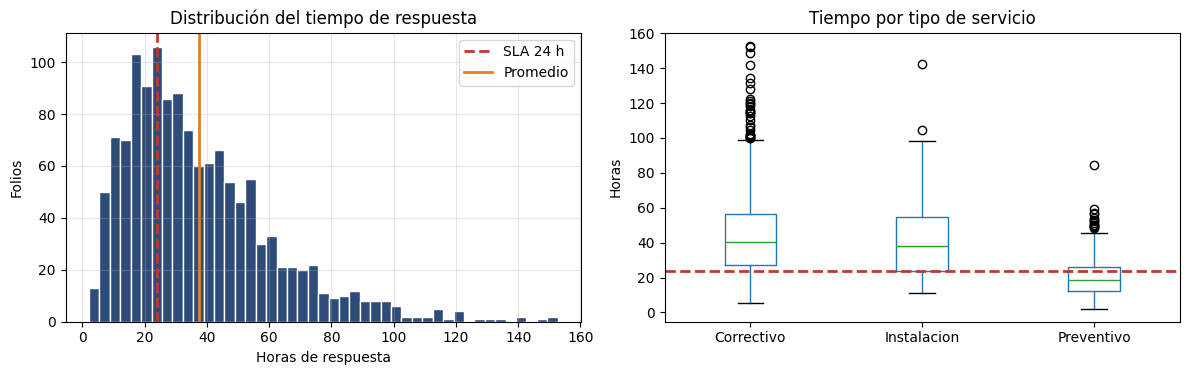

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(d.horas_respuesta, bins=45, color='#2E4B7A', edgecolor='white')
ax[0].axvline(24, color='#C0392B', linestyle='--', linewidth=2, label='SLA 24 h')
ax[0].axvline(d.horas_respuesta.mean(), color='#E67E22', linewidth=2, label='Promedio')
ax[0].set_xlabel('Horas de respuesta'); ax[0].set_ylabel('Folios')
ax[0].set_title('Distribución del tiempo de respuesta'); ax[0].legend()

d.boxplot(column='horas_respuesta', by='tipo_servicio', ax=ax[1], grid=False)
ax[1].axhline(24, color='#C0392B', linestyle='--', linewidth=2)
ax[1].set_title('Tiempo por tipo de servicio'); ax[1].set_xlabel(''); ax[1].set_ylabel('Horas')
plt.suptitle('')
plt.tight_layout(); plt.savefig('../imagenes/01_distribucion.png', dpi=110, bbox_inches='tight')
plt.show()

La distribución tiene una **cola larga a la derecha**: la mayoría de los servicios se resuelve
razonablemente rápido, pero un grupo minoritario tarda muchísimo y arrastra el promedio.
Por eso la mediana es más baja que la media.

Los servicios **preventivos** son mucho más rápidos y predecibles: están programados. Los
**correctivos** son los que rompen el SLA.

### 4.2 ¿El problema es geográfico?

In [8]:
por_region = d.groupby('region').agg(
    folios=('folio', 'count'),
    horas_promedio=('horas_respuesta', 'mean'),
    horas_mediana=('horas_respuesta', 'median'),
    cumplimiento_sla=('cumple_sla', 'mean')
).round(2).sort_values('horas_promedio', ascending=False)

por_region['cumplimiento_sla'] = (por_region['cumplimiento_sla'] * 100).round(1)
por_region

,folios,horas_promedio,horas_mediana,cumplimiento_sla
region,,,,
Sureste,154,42.59,38.00,23.0
Norte,269,41.81,37.50,26.0
Occidente,209,37.03,31.20,33.0
Bajio,250,36.92,32.15,37.0
Centro,455,33.86,28.40,39.0


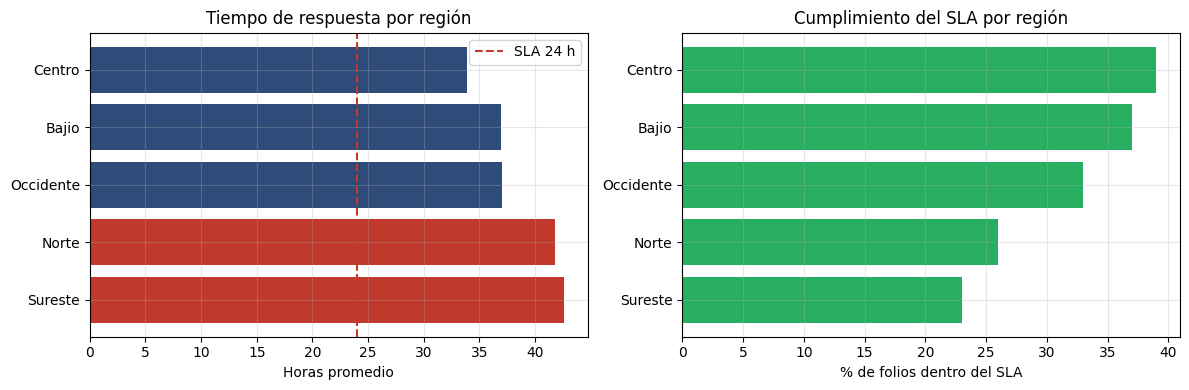

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#C0392B' if v > 40 else '#2E4B7A' for v in por_region.horas_promedio]
ax[0].barh(por_region.index, por_region.horas_promedio, color=colores)
ax[0].axvline(24, color='#C0392B', linestyle='--', label='SLA 24 h')
ax[0].set_xlabel('Horas promedio'); ax[0].set_title('Tiempo de respuesta por región'); ax[0].legend()

sla = por_region.sort_values('cumplimiento_sla')
ax[1].barh(sla.index, sla.cumplimiento_sla, color='#27AE60')
ax[1].set_xlabel('% de folios dentro del SLA'); ax[1].set_title('Cumplimiento del SLA por región')

plt.tight_layout(); plt.savefig('../imagenes/02_regiones.png', dpi=110, bbox_inches='tight')
plt.show()

**Sureste y Norte** son las regiones más lentas, con cumplimiento de SLA por debajo del 27%,
frente al 39% del Centro. Es consistente con lo que se esperaría: mayores distancias y menor
densidad de técnicos.

Pero la brecha entre la mejor y la peor región es de unas **9 horas**. Eso no explica por sí solo
por qué el promedio general está 12 horas por encima del objetivo. Hay que buscar otro factor.

### 4.3 El factor refacciones

In [10]:
por_refaccion = d.groupby('requiere_refaccion').agg(
    folios=('folio', 'count'),
    horas_promedio=('horas_respuesta', 'mean'),
    horas_mediana=('horas_respuesta', 'median'),
    cumplimiento_sla=('cumple_sla', 'mean')
).round(2)
por_refaccion['cumplimiento_sla'] = (por_refaccion['cumplimiento_sla'] * 100).round(1)
print(por_refaccion)

sin_r = d[d.requiere_refaccion == 'No'].horas_respuesta.mean()
con_r = d[d.requiere_refaccion == 'Si'].horas_respuesta.mean()
print(f'\nDiferencia: {con_r - sin_r:.1f} horas adicionales cuando se requiere refacción')
print(f'Los servicios con refacción tardan {con_r/sin_r:.1f} veces más')
print(f'Representan el {(d.requiere_refaccion == "Si").mean():.1%} de todos los folios')

                    folios  horas_promedio  horas_mediana  cumplimiento_sla
requiere_refaccion                                                         
No                     827           26.93           24.1              50.0
Si                     510           54.73           51.1               7.0

Diferencia: 27.8 horas adicionales cuando se requiere refacción
Los servicios con refacción tardan 2.0 veces más
Representan el 38.1% de todos los folios


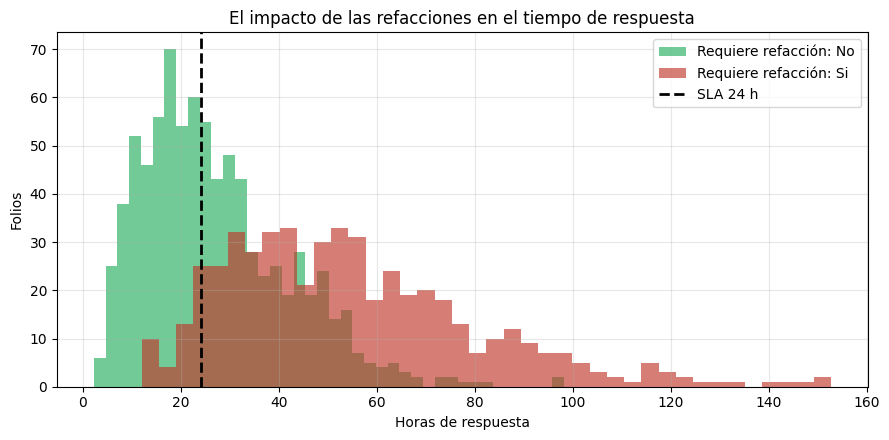

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for etiqueta, color in [('No', '#27AE60'), ('Si', '#C0392B')]:
    sub = d[d.requiere_refaccion == etiqueta].horas_respuesta
    ax.hist(sub, bins=40, alpha=0.65, label=f'Requiere refacción: {etiqueta}', color=color)
ax.axvline(24, color='black', linestyle='--', linewidth=2, label='SLA 24 h')
ax.set_xlabel('Horas de respuesta'); ax.set_ylabel('Folios')
ax.set_title('El impacto de las refacciones en el tiempo de respuesta'); ax.legend()
plt.tight_layout(); plt.savefig('../imagenes/03_refacciones.png', dpi=110, bbox_inches='tight')
plt.show()

**Este es el hallazgo principal.**

Los servicios que requieren una refacción tardan **más del doble**: ~55 horas contra ~27.
Y no son casos aislados: representan cerca del **38% de todos los folios**.

Dicho de otro modo, el problema no es principalmente geográfico ni de desempeño de los técnicos.
Es un problema de **disponibilidad de refacciones**.

### 4.4 ¿Qué fallas concentran el problema?

In [12]:
por_falla = d.groupby('falla_reportada').agg(
    folios=('folio', 'count'),
    horas_promedio=('horas_respuesta', 'mean'),
    pct_con_refaccion=('requiere_refaccion', lambda x: (x == 'Si').mean() * 100)
).round(1).sort_values('horas_promedio', ascending=False)
por_falla

,folios,horas_promedio,pct_con_refaccion
falla_reportada,,,
Falla de compresor,159,51.2,74.2
Fuga de refrigerante,211,50.3,71.6
Puerta / empaque danado,126,49.9,67.5
Termostato descalibrado,168,38.2,17.3
Problema electrico,160,38.0,20.0
Acumulacion de hielo,128,37.2,14.8
Mantenimiento programado,385,20.5,19.7


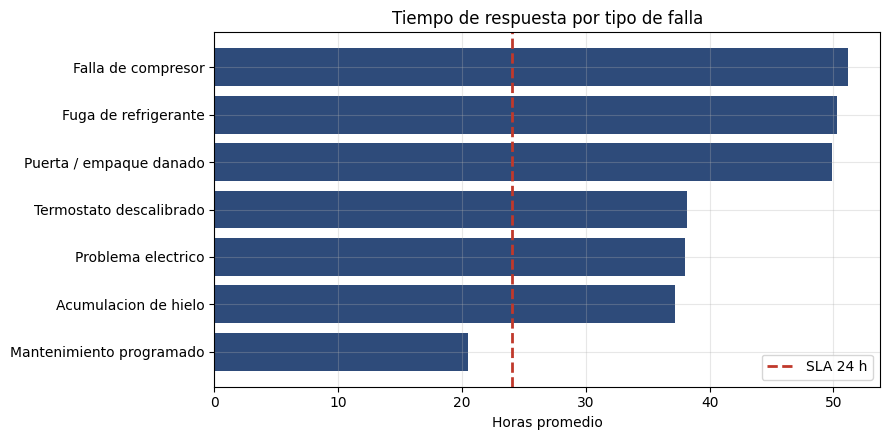

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
p = por_falla.sort_values('horas_promedio')
ax.barh(p.index, p.horas_promedio, color='#2E4B7A')
ax.axvline(24, color='#C0392B', linestyle='--', linewidth=2, label='SLA 24 h')
ax.set_xlabel('Horas promedio'); ax.set_title('Tiempo de respuesta por tipo de falla'); ax.legend()
plt.tight_layout(); plt.savefig('../imagenes/04_fallas.png', dpi=110, bbox_inches='tight')
plt.show()

Las tres fallas más lentas — **compresor, fuga de refrigerante y empaque de puerta** — son
precisamente las que exigen refacción con más frecuencia. Confirma el diagnóstico anterior
y además señala **qué piezas** convendría tener en stock.

### 4.5 Estacionalidad

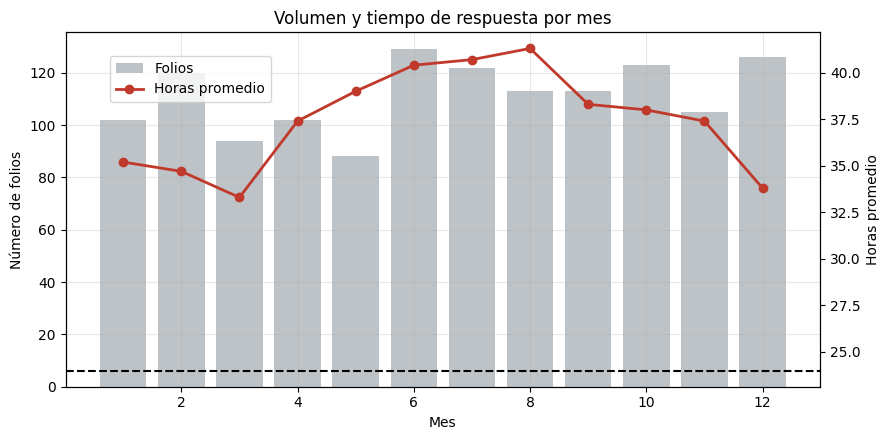

mes                1      2     3      4     5      6      7      8      9   \
folios          102.0  120.0  94.0  102.0  88.0  129.0  122.0  113.0  113.0   
horas_promedio   35.2   34.7  33.3   37.4  39.0   40.4   40.7   41.3   38.3   

mes                10     11     12  
folios          123.0  105.0  126.0  
horas_promedio   38.0   37.4   33.8  


In [14]:
por_mes = d.groupby('mes').agg(
    folios=('folio', 'count'),
    horas_promedio=('horas_respuesta', 'mean')
).round(1)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(por_mes.index, por_mes.folios, color='#BDC3C7', label='Folios')
ax1.set_xlabel('Mes'); ax1.set_ylabel('Número de folios')
ax2 = ax1.twinx()
ax2.plot(por_mes.index, por_mes.horas_promedio, color='#C0392B', marker='o', linewidth=2, label='Horas promedio')
ax2.axhline(24, color='black', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Horas promedio'); ax2.grid(False)
ax1.set_title('Volumen y tiempo de respuesta por mes')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout(); plt.savefig('../imagenes/05_estacionalidad.png', dpi=110, bbox_inches='tight')
plt.show()

print(por_mes.T)

Entre **mayo y agosto** el tiempo de respuesta sube de forma clara. Coincide con la temporada
de calor, cuando los equipos de refrigeración trabajan más y fallan más. La operación se satura
justo cuando más se necesita.

### 4.6 Reincidencias

In [15]:
reinc_global = (d.reincidencia_30d == 'Si').mean()
print(f'Reincidencia a 30 días (global): {reinc_global:.1%}')

reinc = d.groupby('requiere_refaccion').apply(
    lambda x: (x.reincidencia_30d == 'Si').mean() * 100, include_groups=False).round(1)
print('\nReincidencia según refacción:')
print(reinc)

costo_reinc = d[d.reincidencia_30d == 'Si'].costo_servicio.sum()
print(f'\nCosto acumulado de servicios con reincidencia: ${costo_reinc:,.0f} MXN')
print(f'Equivale al {costo_reinc / d.costo_servicio.sum():.1%} del gasto total en servicios')

Reincidencia a 30 días (global): 14.7%

Reincidencia según refacción:
requiere_refaccion
No    12.8
Si    17.8
dtype: float64

Costo acumulado de servicios con reincidencia: $1,579,229 MXN
Equivale al 16.3% del gasto total en servicios


Casi **15 de cada 100 equipos vuelven a fallar en menos de 30 días**, y la tasa es más alta
cuando hubo refacción de por medio. Cada reincidencia es un servicio que se paga dos veces.

## 5. Tabla resumen de KPIs

In [16]:
resumen = pd.DataFrame({
    'KPI': [
        'Folios analizados',
        'Tiempo promedio de respuesta (h)',
        'Tiempo mediano de respuesta (h)',
        'Cumplimiento del SLA de 24 h',
        'Tiempo promedio SIN refacción (h)',
        'Tiempo promedio CON refacción (h)',
        '% de folios que requieren refacción',
        'Tasa de reincidencia a 30 días',
        'Región más lenta',
        'Región más rápida',
    ],
    'Valor': [
        f'{len(d):,}',
        f'{d.horas_respuesta.mean():.1f}',
        f'{d.horas_respuesta.median():.1f}',
        f'{d.cumple_sla.mean():.1%}',
        f'{d[d.requiere_refaccion == "No"].horas_respuesta.mean():.1f}',
        f'{d[d.requiere_refaccion == "Si"].horas_respuesta.mean():.1f}',
        f'{(d.requiere_refaccion == "Si").mean():.1%}',
        f'{(d.reincidencia_30d == "Si").mean():.1%}',
        f'{por_region.index[0]} ({por_region.horas_promedio.iloc[0]:.1f} h)',
        f'{por_region.index[-1]} ({por_region.horas_promedio.iloc[-1]:.1f} h)',
    ]
})
resumen

,KPI,Valor
0,Folios analizados,"1,337"
1,Tiempo promedio de respuesta (h),37.5
2,Tiempo mediano de respuesta (h),32.0
3,Cumplimiento del SLA de 24 h,33.4%
4,Tiempo promedio SIN refacción (h),26.9
5,Tiempo promedio CON refacción (h),54.7
6,% de folios que requieren refacción,38.1%
7,Tasa de reincidencia a 30 días,14.7%
8,Región más lenta,Sureste (42.6 h)
9,Región más rápida,Centro (33.9 h)


## 6. Conclusiones

**1. El SLA se incumple en dos de cada tres servicios.**
El promedio de respuesta es de ~36 horas contra un objetivo de 24.

**2. La causa principal es la disponibilidad de refacciones, no la geografía.**
Un servicio que requiere pieza tarda **más del doble** (55 h contra 27 h) y representa cerca del
**38% de los folios**. La brecha entre regiones, en cambio, es de apenas 9 horas.

**3. El problema se concentra en tres fallas identificables.**
Compresor, fuga de refrigerante y empaque de puerta son las más lentas y las que más refacción exigen.

**4. La operación se satura en verano.**
De mayo a agosto suben tanto el volumen como el tiempo de respuesta.

**5. Casi el 15% de los equipos reincide en 30 días**, lo que significa pagar dos veces por el mismo problema.

---

## 7. Recomendaciones

| # | Acción | Impacto esperado |
|---|---|---|
| 1 | Mantener stock mínimo de compresores, empaques y refrigerante en las bases regionales | Es la palanca de mayor impacto: ataca el 38% de folios más lentos |
| 2 | Reforzar la plantilla técnica en Sureste y Norte | Sube el cumplimiento de SLA en las dos regiones más rezagadas |
| 3 | Anticipar el pico de verano con inventario y personal desde abril | Evita la saturación de mayo a agosto |
| 4 | Auditar los folios con reincidencia a 30 días | Reduce el retrabajo y el costo duplicado |
| 5 | Corregir la captura en origen (fechas invertidas, campos vacíos) | El 6% de los folios se descartó por errores de captura |

---

## 8. Siguientes pasos

- Incorporar la ubicación del técnico para medir el tiempo real de traslado.
- Construir un modelo que anticipe qué folios superarán el SLA al momento de abrirse.
- Llevar estos KPIs a un tablero de actualización semanal.